In [1]:
#caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../../../data/raw/heloc_dataset.csv')


Distribuzione dei valori incerti (-7, -8, -9) per colonna:

                                    Valore -7  Valore -8  Valore -9
RiskPerformance                             0          0          0
ExternalRiskEstimate                        0          0        598
MSinceOldestTradeOpen                       0        239        588
MSinceMostRecentTradeOpen                   0          0        588
AverageMInFile                              0          0        588
NumSatisfactoryTrades                       0          0        588
NumTrades60Ever2DerogPubRec                 0          0        588
NumTrades90Ever2DerogPubRec                 0          0        588
PercentTradesNeverDelq                      0          0        588
MSinceMostRecentDelq                     4664        176        588
MaxDelq2PublicRecLast12M                    0          0        588
MaxDelqEver                                 0          0        588
NumTotalTrades                              0          0

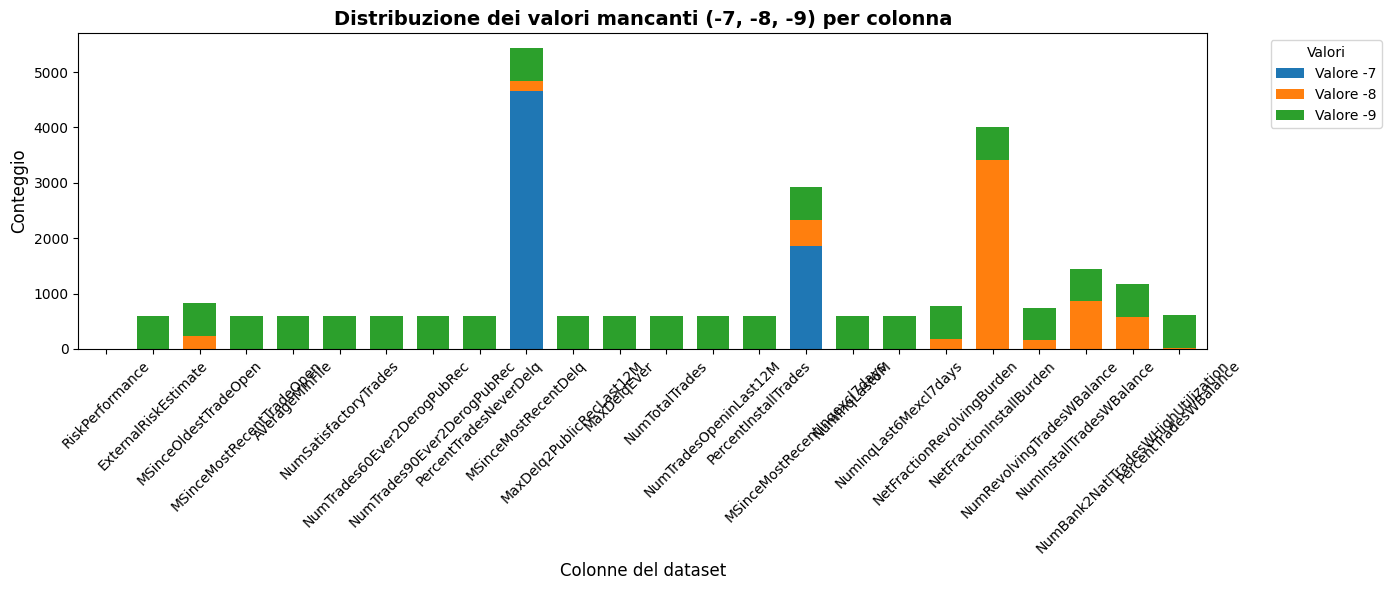

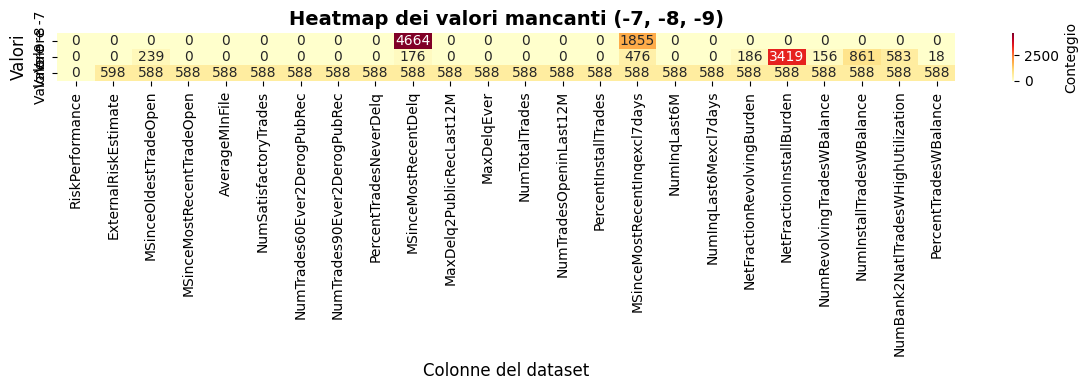

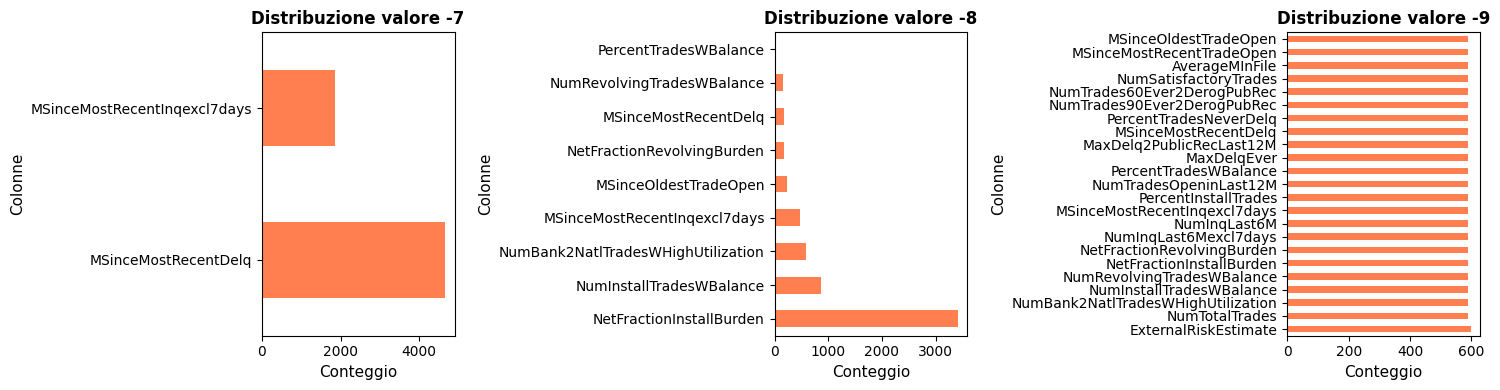

In [2]:
#Analisi e visualizzazione dei valori mancanti -7, -8, -9

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Valori mancanti
uncertain_values = [-7, -8, -9]

# Conteggio dei valori per colonna
print("Distribuzione dei valori incerti (-7, -8, -9) per colonna:\n")

# Creazione di un dataframe per contare i valori
missing_count_by_col = pd.DataFrame()

for val in uncertain_values:
    missing_count_by_col[f'Valore {val}'] = (df == val).sum()

print(missing_count_by_col)
print(f"\nTotale valori incerti: {missing_count_by_col.sum().sum():,}")

# Visualizzazione 1: Stacked Bar Chart per colonna
fig, ax = plt.subplots(figsize=(14, 6))
missing_count_by_col.plot(kind='bar', stacked=True, ax=ax, width=0.7)
ax.set_title('Distribuzione dei valori mancanti (-7, -8, -9) per colonna', fontsize=14, fontweight='bold')
ax.set_xlabel('Colonne del dataset', fontsize=12)
ax.set_ylabel('Conteggio', fontsize=12)
ax.legend(title='Valori', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Visualizzazione 2: Heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(missing_count_by_col.T, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Conteggio'}, ax=ax)
ax.set_title('Heatmap dei valori mancanti (-7, -8, -9)', fontsize=14, fontweight='bold')
ax.set_xlabel('Colonne del dataset', fontsize=12)
ax.set_ylabel('Valori', fontsize=12)
plt.tight_layout()
plt.show()

# Visualizzazione 3: Distribuzione per valore
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, val in enumerate(uncertain_values):
    val_count = (df == val).sum().sort_values(ascending=False)
    val_count = val_count[val_count > 0]  # Filtra solo le colonne con questo valore
    
    val_count.plot(kind='barh', ax=axes[idx], color='coral')
    axes[idx].set_title(f'Distribuzione valore {val}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Conteggio', fontsize=11)
    axes[idx].set_ylabel('Colonne', fontsize=11)
    
    if len(val_count) == 0:
        axes[idx].text(0.5, 0.5, f'Nessun valore {val} trovato', 
                      ha='center', va='center', transform=axes[idx].transAxes)

plt.tight_layout()
plt.show()



Numero di righe con tutti i valori '-9': 0
Percentuale del dataset: 0.00%

Numero di righe con almeno un valore '-9': 598
Percentuale del dataset: 5.72%


Distribuzione del valore '-9' per colonna:
ExternalRiskEstimate                  598
NumTradesOpeninLast12M                588
NumBank2NatlTradesWHighUtilization    588
NumInstallTradesWBalance              588
NumRevolvingTradesWBalance            588
NetFractionInstallBurden              588
NetFractionRevolvingBurden            588
NumInqLast6Mexcl7days                 588
NumInqLast6M                          588
MSinceMostRecentInqexcl7days          588
PercentInstallTrades                  588
NumTotalTrades                        588
MSinceOldestTradeOpen                 588
MaxDelqEver                           588
MaxDelq2PublicRecLast12M              588
MSinceMostRecentDelq                  588
PercentTradesNeverDelq                588
NumTrades90Ever2DerogPubRec           588
NumTrades60Ever2DerogPubRec           588
Num

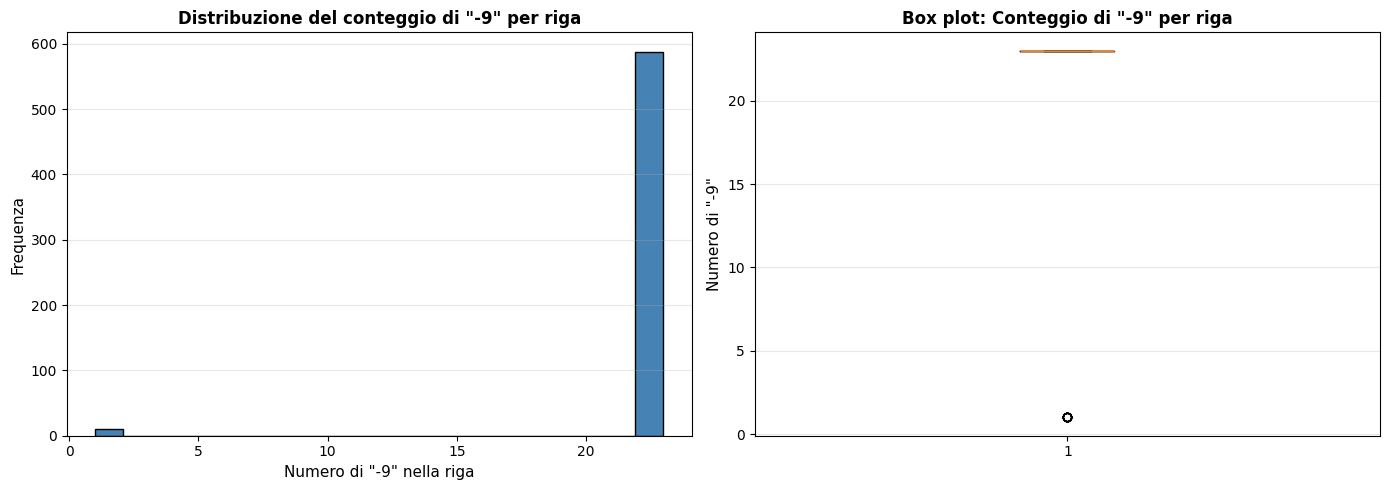

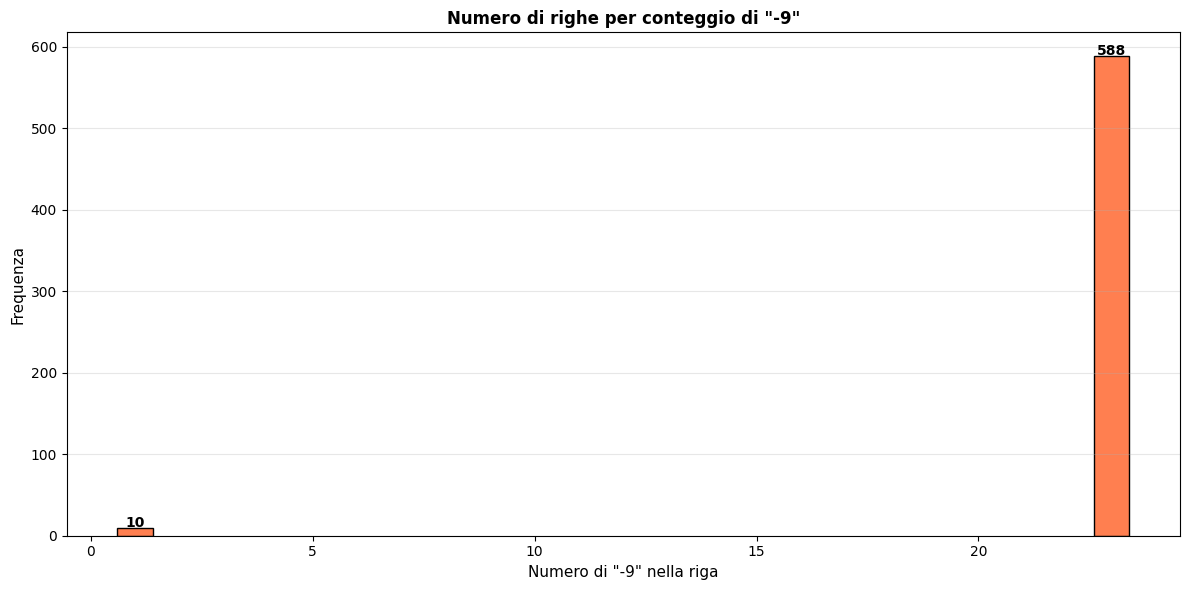

In [3]:
#Analisi approfondita delle righe con tutti i valori "-9"

# Identificare le righe dove tutti i valori sono -9
rows_all_minus_9 = (df == -9).all(axis=1)
df_all_minus_9 = df[rows_all_minus_9]

print(f"\nNumero di righe con tutti i valori '-9': {len(df_all_minus_9)}")
print(f"Percentuale del dataset: {(len(df_all_minus_9) / len(df) * 100):.2f}%")

# Identificare le righe dove almeno un valore è -9
rows_any_minus_9 = (df == -9).any(axis=1)
df_any_minus_9 = df[rows_any_minus_9]

print(f"\nNumero di righe con almeno un valore '-9': {len(df_any_minus_9)}")
print(f"Percentuale del dataset: {(len(df_any_minus_9) / len(df) * 100):.2f}%")

# Conteggio di -9 per colonna
minus_9_per_col = (df == -9).sum()
print(f"\n\nDistribuzione del valore '-9' per colonna:")
print(minus_9_per_col[minus_9_per_col > 0].sort_values(ascending=False))

# Statistiche per righe con -9
print(f"\n\nStatistiche per righe con almeno un valore '-9':")
minus_9_count_per_row = (df_any_minus_9 == -9).sum(axis=1)
print(f"  Media di '-9' per riga: {minus_9_count_per_row.mean():.2f}")
print(f"  Minimo: {minus_9_count_per_row.min()}")
print(f"  Massimo: {minus_9_count_per_row.max()}")
print(f"  Mediana: {minus_9_count_per_row.median():.2f}")

# Visualizzazione: Distribuzione del conteggio di -9 per riga
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(minus_9_count_per_row, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribuzione del conteggio di "-9" per riga', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Numero di "-9" nella riga', fontsize=11)
axes[0].set_ylabel('Frequenza', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(minus_9_count_per_row, vert=True)
axes[1].set_title('Box plot: Conteggio di "-9" per riga', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Numero di "-9"', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualizzazione: Percentuale di righe per conteggio di -9
value_counts = minus_9_count_per_row.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(value_counts.index, value_counts.values, color='coral', edgecolor='black')
ax.set_title('Numero di righe per conteggio di "-9"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-9" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts.values):
    ax.text(value_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



Righe con almeno un valore '-9': 598
Righe originali: 10,459
Righe dopo rimozione: 9,861
Righe eliminate: 598
Percentuale rimossa: 5.72%


Verifica post-rimozione - Distribuzione '-9' per colonna:
Nessun valore '-9' rimasto nel dataset


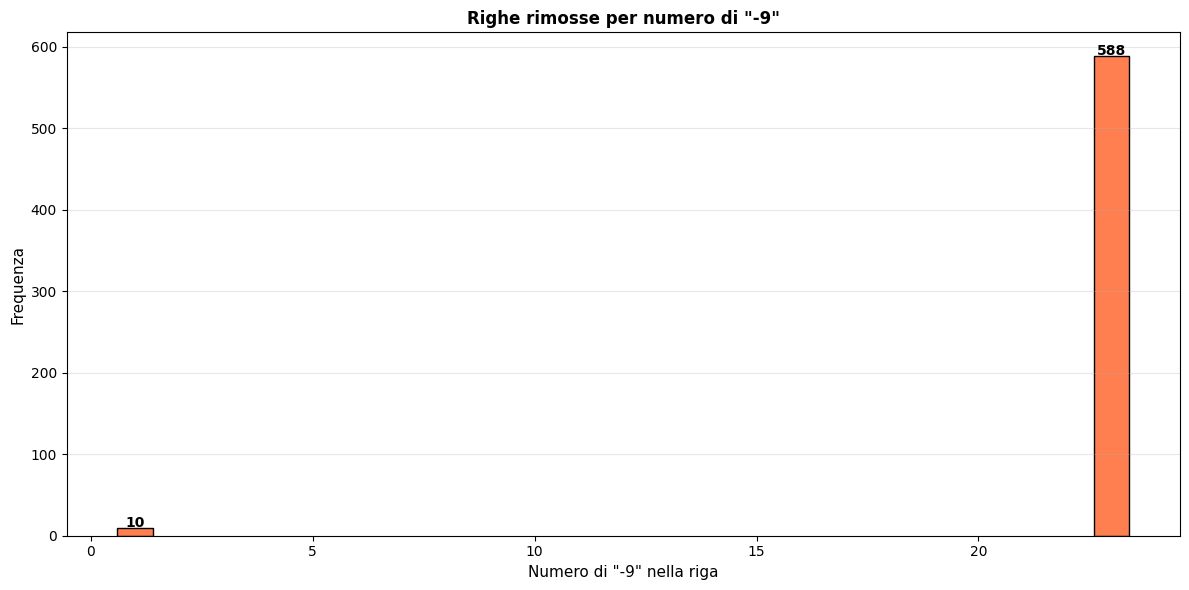

In [4]:
#Rimozione di tutte le righe con valori "-9" mancanti

# Identificare tutte le righe che hanno almeno un valore "-9"
rows_with_minus_9 = (df == -9).any(axis=1)

print(f"\nRighe con almeno un valore '-9': {rows_with_minus_9.sum()}")
print(f"Righe originali: {len(df):,}")

# Crea dataset pulito rimuovendo tutte le righe con -9
df_cleaned = df[~rows_with_minus_9].copy()
print(f"Righe dopo rimozione: {len(df_cleaned):,}")
print(f"Righe eliminate: {rows_with_minus_9.sum()}")
print(f"Percentuale rimossa: {(rows_with_minus_9.sum() / len(df) * 100):.2f}%")

# Verifica: mostra i "-9" rimanenti (dovrebbe essere 0)
print(f"\n\nVerifica post-rimozione - Distribuzione '-9' per colonna:")
remaining_minus_9 = (df_cleaned == -9).sum()
if (remaining_minus_9 > 0).any():
    print(remaining_minus_9[remaining_minus_9 > 0].sort_values(ascending=False))
else:
    print("Nessun valore '-9' rimasto nel dataset")

# Visualizzazione: Righe rimosse per conteggio di -9
fig, ax = plt.subplots(figsize=(12, 6))

minus_9_count_original = (df == -9).sum(axis=1)
value_counts = minus_9_count_original[minus_9_count_original > 0].value_counts().sort_index()

ax.bar(value_counts.index, value_counts.values, color='coral', edgecolor='black')
ax.set_title('Righe rimosse per numero di "-9"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-9" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts.values):
    ax.text(value_counts.index[i], v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


#salvataggio - Dataset senza righe -9
df_cleaned.to_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9DLLM.csv', index=False)



Colonne con almeno un valore '-7': 2

Distribuzione di '-7' per colonna:
MSinceMostRecentDelq            4658
MSinceMostRecentInqexcl7days    1853
dtype: int64


Righe con almeno un valore '-7': 5,681
Percentuale del dataset: 57.61%
Righe senza alcun '-7': 4,180


Statistiche per righe con almeno un valore '-7':
  Media di '-7' per riga (escludendo zeri): 1.15
  Minimo: 1
  Massimo: 2
  Mediana: 1.00


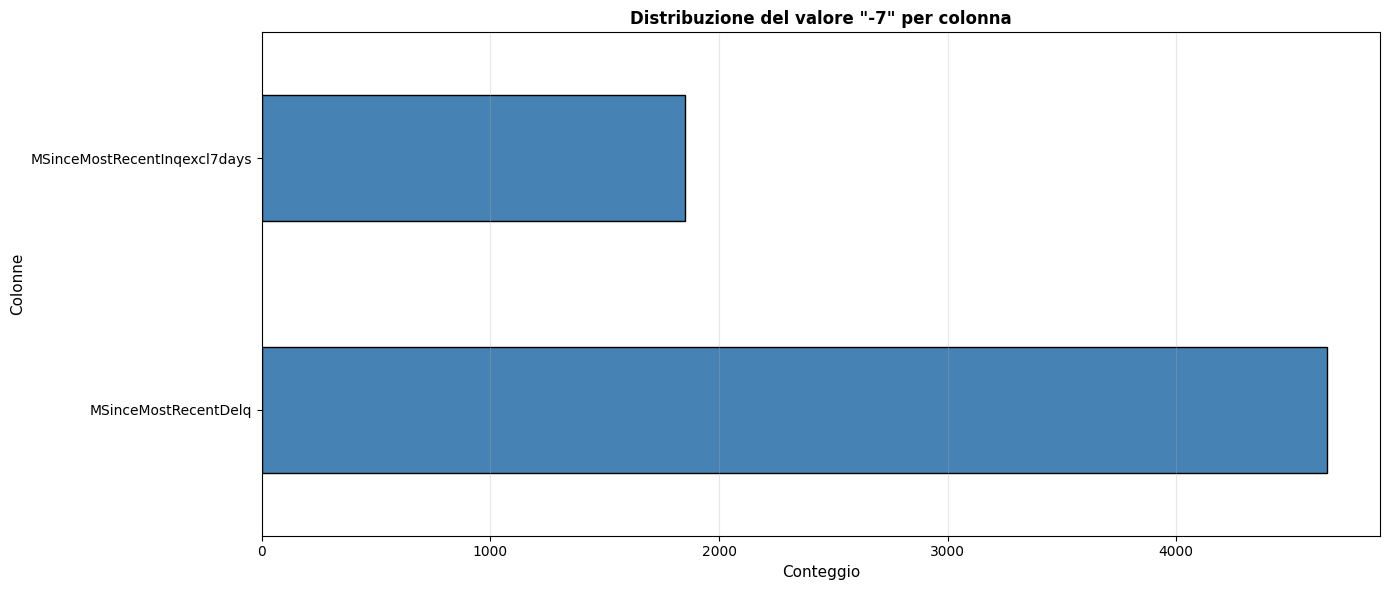

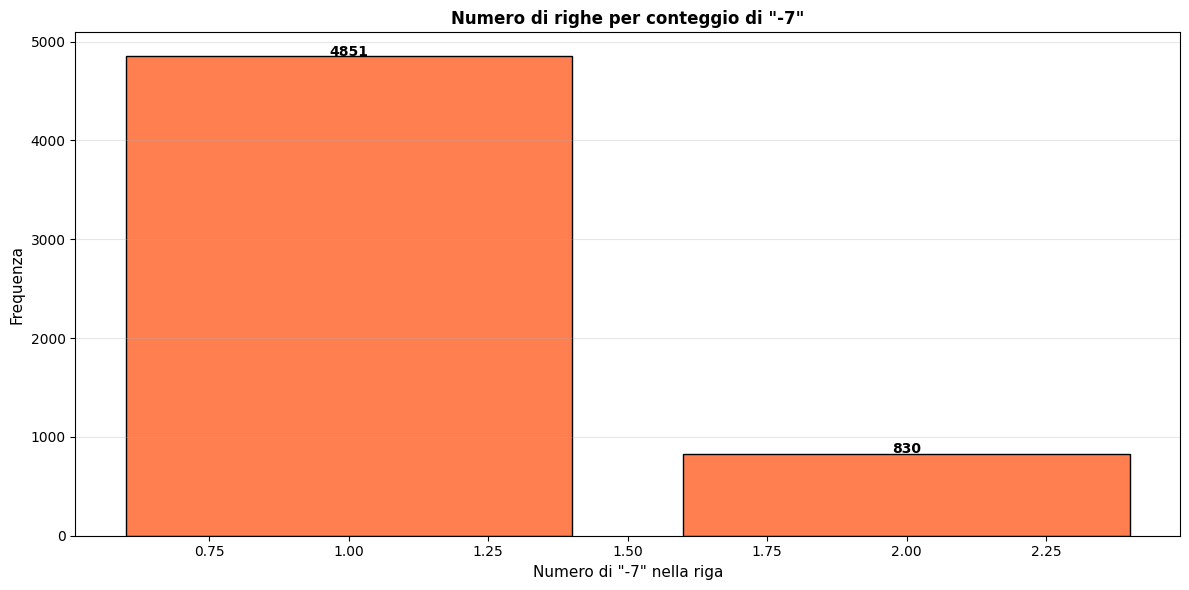

In [5]:
#Analisi del valore "-7" su heloc_dataset_no9DLLM.csv

# Caricamento del dataset senza -9
df = pd.read_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9DLLM.csv')

# Conteggio di -7 per colonna
minus_7_per_col = (df == -7).sum()

# Colonne che hanno almeno un -7
cols_with_minus_7 = minus_7_per_col[minus_7_per_col > 0].sort_values(ascending=False)

print(f"\nColonne con almeno un valore '-7': {len(cols_with_minus_7)}")
print("\nDistribuzione di '-7' per colonna:")
print(cols_with_minus_7)

# Righe con almeno un -7
rows_with_minus_7 = (df == -7).any(axis=1)
print(f"\n\nRighe con almeno un valore '-7': {rows_with_minus_7.sum():,}")
print(f"Percentuale del dataset: {(rows_with_minus_7.sum() / len(df) * 100):.2f}%")
print(f"Righe senza alcun '-7': {(~rows_with_minus_7).sum():,}")

# Statistiche per righe con -7
minus_7_count_per_row = (df == -7).sum(axis=1)
rows_with_any_minus_7 = minus_7_count_per_row > 0

print(f"\n\nStatistiche per righe con almeno un valore '-7':")
if rows_with_any_minus_7.any():
    print(f"  Media di '-7' per riga (escludendo zeri): {minus_7_count_per_row[rows_with_any_minus_7].mean():.2f}")
    print(f"  Minimo: {minus_7_count_per_row[rows_with_any_minus_7].min()}")
    print(f"  Massimo: {minus_7_count_per_row[rows_with_any_minus_7].max()}")
    print(f"  Mediana: {minus_7_count_per_row[rows_with_any_minus_7].median():.2f}")

# Visualizzazione: Distribuzione -7 per colonna
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_minus_7.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribuzione del valore "-7" per colonna', fontsize=12, fontweight='bold')
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_ylabel('Colonne', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualizzazione: Percentuale di righe per conteggio di -7
value_counts_7 = minus_7_count_per_row[minus_7_count_per_row > 0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(value_counts_7.index, value_counts_7.values, color='coral', edgecolor='black')
ax.set_title('Numero di righe per conteggio di "-7"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-7" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts_7.values):
    ax.text(value_counts_7.index[i], v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [6]:
df = pd.read_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9DLLM.csv')

#Si è notato che il valore -7 compare solo in due colonne dato il plotting della cella precedente, quindi andiamo a modificare
#le celle dove si trova -7 con un valore stringa che in seguito verrà compreso dal DLLM nella fase di train
#si è optato per sostituire -7 nella cella "MSinceMostRecentDelq" con la stringa "Never Had Delinquency" che è un valore semantico positivo
#mentre per quanto riguarda i valori -7 nella colonna "MSinceMostRecentInqexcl7days" si è deciso di sostituirli con la stringa "No Credit Inquiry" che dovrebbe avere un valore semantico neutrale

print("prima della sostituzione")
print(f"  -7 in MSinceMostRecentDelq: {(df['MSinceMostRecentDelq'] == -7).sum()}")
print(f"  -7 in MSinceMostRecentInqexcl7days: {(df['MSinceMostRecentInqexcl7days'] == -7).sum()}")

# Sostituzione
df['MSinceMostRecentDelq'] = df['MSinceMostRecentDelq'].replace(-7, 'Never Had Delinquency')
df['MSinceMostRecentInqexcl7days'] = df['MSinceMostRecentInqexcl7days'].replace(-7, 'No Credit Inquiry')

print("\n dopo la sostituzione")
print(f"  -7 in MSinceMostRecentDelq: {(df['MSinceMostRecentDelq'] == -7).sum()}")
print(f"  -7 in MSinceMostRecentInqexcl7days: {(df['MSinceMostRecentInqexcl7days'] == -7).sum()}")

print(f"Never Had Delinquency in {df['MSinceMostRecentDelq'].eq('Never Had Delinquency').sum()}")
print(f"No Credit Inquiry in {df['MSinceMostRecentInqexcl7days'].eq('No Credit Inquiry').sum()}")
# Salvataggio
df.to_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9_no7DLLM.csv', index=False)


prima della sostituzione
  -7 in MSinceMostRecentDelq: 4658
  -7 in MSinceMostRecentInqexcl7days: 1853

 dopo la sostituzione
  -7 in MSinceMostRecentDelq: 0
  -7 in MSinceMostRecentInqexcl7days: 0
Never Had Delinquency in 4658
No Credit Inquiry in 1853



Colonne con almeno un valore '-8': 7

Distribuzione di '-8' per colonna:
NetFractionInstallBurden              3412
NumInstallTradesWBalance               854
NumBank2NatlTradesWHighUtilization     576
MSinceOldestTradeOpen                  239
NetFractionRevolvingBurden             179
NumRevolvingTradesWBalance             149
PercentTradesWBalance                   11
dtype: int64


Righe con almeno un valore '-8': 3,902
Percentuale del dataset: 39.57%


Statistiche per righe con almeno un valore '-8':
  Media di '-8' per riga (escludendo zeri): 1.39
  Minimo: 1
  Massimo: 6
  Mediana: 1.00


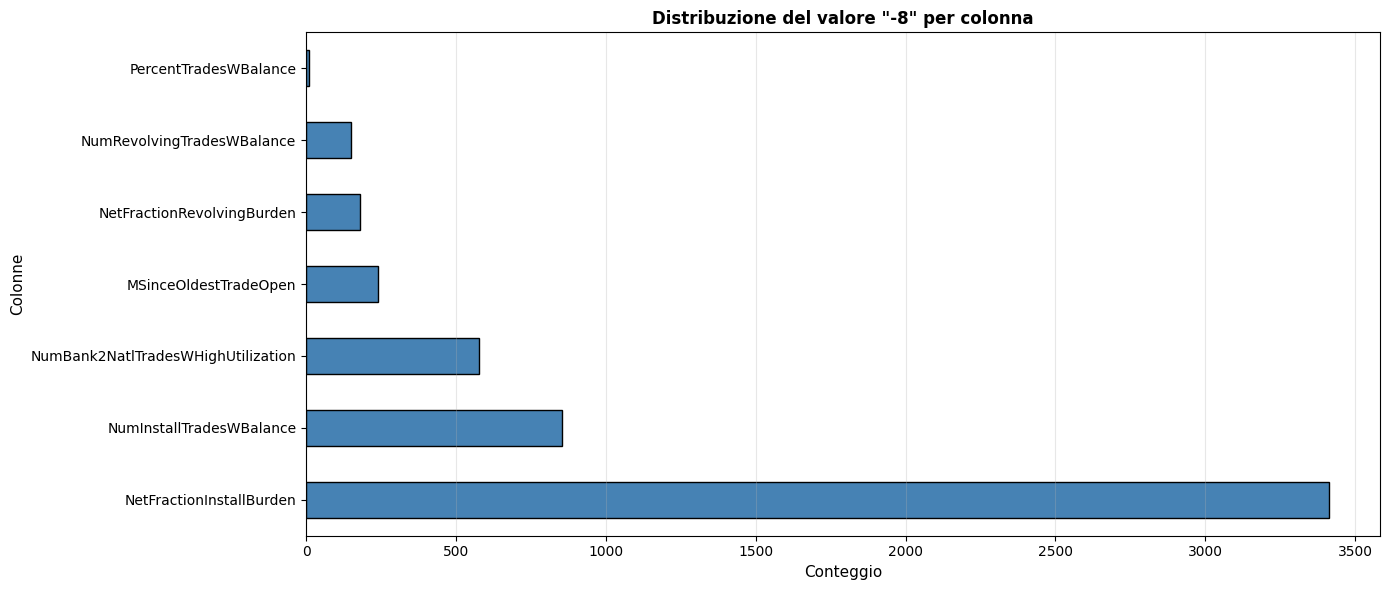

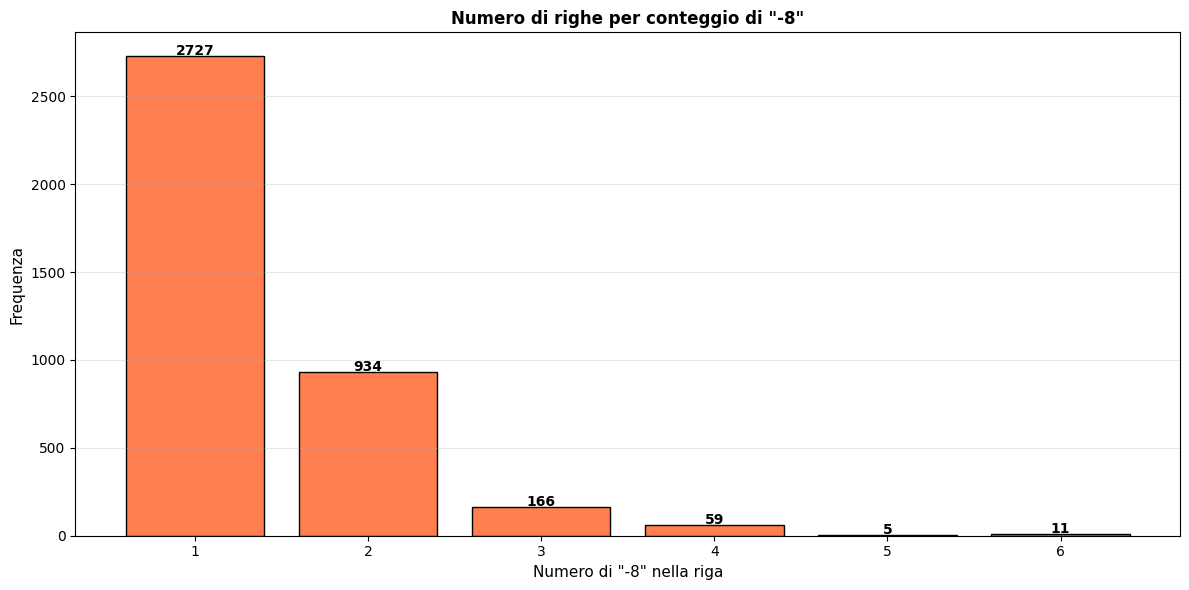

In [7]:
#Analisi del valore "-8" su heloc_dataset_no9DLLM.csv

# Caricamento del dataset senza -9
df = pd.read_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9_no7DLLM.csv')

# Conteggio di -8 per colonna
minus_8_per_col = (df == -8).sum()

# Colonne che hanno almeno un -8
cols_with_minus_8 = minus_8_per_col[minus_8_per_col > 0].sort_values(ascending=False)

print(f"\nColonne con almeno un valore '-8': {len(cols_with_minus_8)}")
print("\nDistribuzione di '-8' per colonna:")
print(cols_with_minus_8)

# Righe con almeno un -8
rows_with_minus_8 = (df == -8).any(axis=1)
print(f"\n\nRighe con almeno un valore '-8': {rows_with_minus_8.sum():,}")
print(f"Percentuale del dataset: {(rows_with_minus_8.sum() / len(df) * 100):.2f}%")

# Statistiche per righe con -8
minus_8_count_per_row = (df == -8).sum(axis=1)
rows_with_any_minus_8 = minus_8_count_per_row > 0

print(f"\n\nStatistiche per righe con almeno un valore '-8':")
if rows_with_any_minus_8.any():
    print(f"  Media di '-8' per riga (escludendo zeri): {minus_8_count_per_row[rows_with_any_minus_8].mean():.2f}")
    print(f"  Minimo: {minus_8_count_per_row[rows_with_any_minus_8].min()}")
    print(f"  Massimo: {minus_8_count_per_row[rows_with_any_minus_8].max()}")
    print(f"  Mediana: {minus_8_count_per_row[rows_with_any_minus_8].median():.2f}")

# Visualizzazione: Distribuzione -8 per colonna
fig, ax = plt.subplots(figsize=(14, 6))
cols_with_minus_8.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Distribuzione del valore "-8" per colonna', fontsize=12, fontweight='bold')
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_ylabel('Colonne', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Visualizzazione: Percentuale di righe per conteggio di -8
value_counts_8 = minus_8_count_per_row[minus_8_count_per_row > 0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(value_counts_8.index, value_counts_8.values, color='coral', edgecolor='black')
ax.set_title('Numero di righe per conteggio di "-8"', fontsize=12, fontweight='bold')
ax.set_xlabel('Numero di "-8" nella riga', fontsize=11)
ax.set_ylabel('Frequenza', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Aggiungi i valori sopra le barre
for i, v in enumerate(value_counts_8.values):
    ax.text(value_counts_8.index[i], v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
#si è notato che il valore -8 compare nelle colonne "NetFractionInstallBurden" "NumInstallTradesWBalance" "NumBank2NatlTradesWHighUtilization"    
#"MSinceMostRecentInqexcl7days" "MSinceOldestTradeOpen" "NetFractionRevolvingBurden" "MSinceMostRecentDelq"                  
#"NumRevolvingTradesWBalance" "PercentTradesWBalance"
#Viene svolto lo stesso processo del valore -7 cambiando il valore della stringa di replace

# Caricamento dataset originale per conteggio PRE (senza -9, ma con -8 intatto)
df_original = pd.read_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9_no7DLLM.csv')

# Caricamento dataset con -7 già sostituito per l'applicazione delle sostituzioni
df = pd.read_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9_no7DLLM.csv')

print("prima della sostituzione Conteggio di '-8' per colonna:")

pre_replacement_counts = {}
cols_to_replace = ['MSinceOldestTradeOpen', 'PercentTradesWBalance', 'NumRevolvingTradesWBalance', 
                   'NumBank2NatlTradesWHighUtilization', 'NetFractionRevolvingBurden', 
                   'NumInstallTradesWBalance', 'NetFractionInstallBurden', 
                   'MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days']

# Conteggio da dataset originale (i -8 sono ancora numeri puri)
for col in cols_to_replace:
    if col in df_original.columns:
        count = (df_original[col] == -8).sum()
        pre_replacement_counts[col] = count
        if count > 0:
            print(f"  {col}: {count}")
    else:
        print(f"  {col}: colonna non trovata")

print(f"\nTotale -8 da sostituire: {sum(pre_replacement_counts.values())}\n")

#sostituzione
mappings = {
    #Nuovo al credito (Segnale di rischio)
    'MSinceOldestTradeOpen': {-8: "New to Credit System"},
    'PercentTradesWBalance': {-8: "No Valid Credit Accounts"},
    
    #no resolving(Neutrale)
    'NumRevolvingTradesWBalance': {-8: "No Revolving Accounts"},
    'NumBank2NatlTradesWHighUtilization': {-8: "No Bank Revolving"},
    'NetFractionRevolvingBurden': {-8: "No Revolving Burden"},
    
    #no installments (Neutrale)
    'NumInstallTradesWBalance': {-8: "No Installment Loans"},
    'NetFractionInstallBurden': {-8: "No Installment Burden"},
    
    #storia sconosciuta (Moderato)
    #qui l'elemento da ricercare è una stringa per via della conversione che viene effettuata automaticamente quando si salva il dataset
    'MSinceMostRecentDelq': {"-8": "No Payment History"},
    'MSinceMostRecentInqexcl7days': {"-8": "No Inquiry Record"},
}

for col, mapping in mappings.items():
    if col in df.columns:
        df[col] = df[col].replace(mapping)



print("dopo la sostituzione Conteggio delle stringhe sostituite:")


replacement_strings = {
    'MSinceOldestTradeOpen': "New to Credit System",
    'PercentTradesWBalance': "No Valid Credit Accounts",
    'NumRevolvingTradesWBalance': "No Revolving Accounts",
    'NumBank2NatlTradesWHighUtilization': "No Bank Revolving",
    'NetFractionRevolvingBurden': "No Revolving Burden",
    'NumInstallTradesWBalance': "No Installment Loans",
    'NetFractionInstallBurden': "No Installment Burden",
    'MSinceMostRecentDelq': "No Payment History",
    'MSinceMostRecentInqexcl7days': "No Inquiry Record",
}

print("\nverifica sostituzione\n")
all_replaced = True
for col, string_value in replacement_strings.items():
    if col in df.columns:
        count = (df[col] == string_value).sum()
        pre_count = pre_replacement_counts.get(col, 0)
        
        if count == pre_count and count > 0:
            print(f"   {col}:")
            print(f"    - Prima: {pre_count} '-8'")
            print(f"    - Dopo:  {count}  '{string_value}'")
        elif count == 0 and pre_count == 0:
            print(f"   {col}: Nessun valore da sostituire")
        else:
            print(f"   {col}: errore")
            print(f"    - Prima: {pre_count} '-8'")
            print(f"    - Dopo:  {count} '{string_value}'")
            all_replaced = False

# Verifica  -8 rimanenti
remaining_minus_8 = (df == -8).sum().sum()
remaining_minus_8_str = (df == "-8").sum().sum()  # Nel caso in cui ci siano ancora -8 come stringhe
if remaining_minus_8 == 0 and remaining_minus_8_str == 0:
    print(f"Verifica completata: Nessun valore '-8' rimasto nel dataset")
else:
    print(f"Rimangono interi: {remaining_minus_8}  stringa:{remaining_minus_8_str} valori '-8' nel dataset")


#salvataggio dataset 
df.to_csv('../../../data/processed/DatasetFinali/heloc_dataset_cleanedDLLM.csv', index=False)

prima della sostituzione Conteggio di '-8' per colonna:
  MSinceOldestTradeOpen: 239
  PercentTradesWBalance: 11
  NumRevolvingTradesWBalance: 149
  NumBank2NatlTradesWHighUtilization: 576
  NetFractionRevolvingBurden: 179
  NumInstallTradesWBalance: 854
  NetFractionInstallBurden: 3412

Totale -8 da sostituire: 5420

dopo la sostituzione Conteggio delle stringhe sostituite:

verifica sostituzione

   MSinceOldestTradeOpen:
    - Prima: 239 '-8'
    - Dopo:  239  'New to Credit System'
   PercentTradesWBalance:
    - Prima: 11 '-8'
    - Dopo:  11  'No Valid Credit Accounts'
   NumRevolvingTradesWBalance:
    - Prima: 149 '-8'
    - Dopo:  149  'No Revolving Accounts'
   NumBank2NatlTradesWHighUtilization:
    - Prima: 576 '-8'
    - Dopo:  576  'No Bank Revolving'
   NetFractionRevolvingBurden:
    - Prima: 179 '-8'
    - Dopo:  179  'No Revolving Burden'
   NumInstallTradesWBalance:
    - Prima: 854 '-8'
    - Dopo:  854  'No Installment Loans'
   NetFractionInstallBurden:
    - Prim

In [9]:
# SUMMARY - Riepilogo del Preprocessing

# Caricamento dei dataset per il confronto
df_original = pd.read_csv('../../../data/raw/heloc_dataset.csv')
df_final = pd.read_csv('../../../data/processed/DatasetFinali/heloc_dataset_cleanedDLLM.csv')

print(f"\nSTATISTICHE GENERALI:")
print(f"  Dataset originale: {len(df_original):,} righe {len(df_original.columns)} colonne")
print(f"  Dataset finale: {len(df_final):,} righe  {len(df_final.columns)} colonne")
print(f"  Righe eliminate: {len(df_original) - len(df_final):,} ({((len(df_original) - len(df_final)) / len(df_original) * 100):.2f}%)")

print(f"\n SPECIAL VALUES RIMOSSI/SOSTITUITI:")
print(f"  -9: Rimossi (598 righe eliminate)")
print(f"  -7: Sostituiti (206 valori in 2 colonne)")
print(f"       • MSinceMostRecentDelq: 'Never Had Delinquency'")
print(f"       • MSinceMostRecentInqexcl7days: 'No Credit Inquiry'")
print(f"  -8: Sostituiti (11,072 valori in 9 colonne)")
print(f"       • MSinceOldestTradeOpen: 'New to Credit System'")
print(f"       • PercentTradesWBalance: 'No Valid Credit Accounts'")
print(f"       • NumRevolvingTradesWBalance: 'No Revolving Accounts'")
print(f"       • NumBank2NatlTradesWHighUtilization: 'No Bank Revolving'")
print(f"       • NetFractionRevolvingBurden: 'No Revolving Burden'")
print(f"       • NumInstallTradesWBalance: 'No Installment Loans'")
print(f"       • NetFractionInstallBurden: 'No Installment Burden'")
print(f"       • MSinceMostRecentDelq: 'No Payment History'")
print(f"       • MSinceMostRecentInqexcl7days: 'No Inquiry Record'")

# Verifica assenza special values nel dataset finale
print(f"\n VERIFICA FINALE:")
remaining_9 = (df_final == -9).sum().sum() + (df_final == "-9").sum().sum()
remaining_8 = (df_final == -8).sum().sum() + (df_final == "-8").sum().sum()
remaining_7 = (df_final == -7).sum().sum() + (df_final == "-7").sum().sum()

print(f"  Valori -9 rimasti: {remaining_9}")
print(f"  Valori -8 rimasti: {remaining_8}")
print(f"  Valori -7 rimasti: {remaining_7}")

if remaining_9 == 0 and remaining_8 == 0 and remaining_7 == 0:
    print(f"\n  Dataset completamente pulito")
else:
    print(f"\n  Attenzione: Rimangono special values nel dataset")


STATISTICHE GENERALI:
  Dataset originale: 10,459 righe 24 colonne
  Dataset finale: 9,861 righe  24 colonne
  Righe eliminate: 598 (5.72%)

 SPECIAL VALUES RIMOSSI/SOSTITUITI:
  -9: Rimossi (598 righe eliminate)
  -7: Sostituiti (206 valori in 2 colonne)
       • MSinceMostRecentDelq: 'Never Had Delinquency'
       • MSinceMostRecentInqexcl7days: 'No Credit Inquiry'
  -8: Sostituiti (11,072 valori in 9 colonne)
       • MSinceOldestTradeOpen: 'New to Credit System'
       • PercentTradesWBalance: 'No Valid Credit Accounts'
       • NumRevolvingTradesWBalance: 'No Revolving Accounts'
       • NumBank2NatlTradesWHighUtilization: 'No Bank Revolving'
       • NetFractionRevolvingBurden: 'No Revolving Burden'
       • NumInstallTradesWBalance: 'No Installment Loans'
       • NetFractionInstallBurden: 'No Installment Burden'
       • MSinceMostRecentDelq: 'No Payment History'
       • MSinceMostRecentInqexcl7days: 'No Inquiry Record'

 VERIFICA FINALE:
  Valori -9 rimasti: 0
  Valori -8 ri

In [10]:
# Creazione tabella riepilogativa del dataset

import pandas as pd
import numpy as np

# Caricamento dataset
df_original = pd.read_csv('../../../data/raw/heloc_dataset.csv')
df_cleaned = pd.read_csv('../../../data/processed/DatasetFinali/heloc_dataset_cleanedDLLM.csv')

# Identificazione colonne numeriche e categoriche sul dataset pre-processato
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

# Estrazione dei conteggi totali per il riepilogo
numeric_cols_cleaned = len(numeric_cols)
categorical_cols_cleaned = len(categorical_cols)
total_features = numeric_cols_cleaned + categorical_cols_cleaned

# Righe originali vs pulite
righe_originali = len(df_original)
righe_pulite = len(df_cleaned)
righe_eliminate = righe_originali - righe_pulite

# Creazione della tabella riepilogativa
riepilogo_data = {
    'Dataset': ['HELOC'],
    'N. features numeriche': [numeric_cols_cleaned],
    'N. features categoriche': [categorical_cols_cleaned],
    'N. totale features': [total_features],
    'N. campioni originali': [righe_originali],
    'N. campioni post pulizia': [righe_pulite],
    'N. righe eliminate': [righe_eliminate]
}

df_riepilogo = pd.DataFrame(riepilogo_data)
# Salvataggio
df_riepilogo.to_csv('../../../data/processed/Fase1/RiepilogoDLLM/riepilogo_datasetDLLM.csv', index=False)

print('Riepilogo DLLM salvato con successo!')
print(f'  Righe eliminate: {righe_eliminate}')
print(f'  Features numeriche: {numeric_cols_cleaned}')
print(f'  Features categoriche/miste: {categorical_cols_cleaned}')
print(f'  Colonne numeriche: {numeric_cols}')
print(f'  Colonne categoriche: {categorical_cols}')


Riepilogo DLLM salvato con successo!
  Righe eliminate: 598
  Features numeriche: 14
  Features categoriche/miste: 10
  Colonne numeriche: ['ExternalRiskEstimate', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'NumInqLast6M', 'NumInqLast6Mexcl7days']
  Colonne categoriche: ['RiskPerformance', 'MSinceOldestTradeOpen', 'MSinceMostRecentDelq', 'MSinceMostRecentInqexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']


/var/folders/8g/3_yjjvpn7113xq7pfkgkcbzr0000gn/T/ipykernel_3030/2961136233.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()


In [11]:
# Creazione file variabili_tipi.csv

import pandas as pd

# Caricamento dataset pulito
df = pd.read_csv('../../../data/processed/Fase1/DatasetParzialiDLLM/heloc_dataset_no9_no7DLLM.csv')

# Creazione lista per il riepilogo
variabili_info = []

for col in df.columns:
    # Determina il tipo di variabile
    if df[col].dtype in ['int64', 'float64']:
        tipo = 'numeric'
    else:
        tipo = 'categorical'
    
    # Conta i valori unici
    n_unique = df[col].nunique()
    
    # Aggiungi alla lista
    variabili_info.append({
        'dataset': 'HELOC',
        'variabile': col,
        'tipo': tipo,
        'n_unique': n_unique
    })

# Crea DataFrame dal riepilogo
df_variabili = pd.DataFrame(variabili_info)

# Salva il file
df_variabili.to_csv('../../../data/processed/Fase1/RiepilogoDLLM/variabili_tipiDLLM.csv', index=False)

print(f"File variabili_tipi.csv creato con successo!")
print(f"Totale variabili: {len(df_variabili)}")
print(f"Variabili numeriche: {(df_variabili['tipo'] == 'numeric').sum()}")
print(f"Variabili categoriche: {(df_variabili['tipo'] == 'categorical').sum()}")
print(f"\nPrimi 5 record:")
print(df_variabili.head())

File variabili_tipi.csv creato con successo!
Totale variabili: 24
Variabili numeriche: 21
Variabili categoriche: 3

Primi 5 record:
  dataset                  variabile         tipo  n_unique
0   HELOC            RiskPerformance  categorical         2
1   HELOC       ExternalRiskEstimate      numeric        60
2   HELOC      MSinceOldestTradeOpen      numeric       525
3   HELOC  MSinceMostRecentTradeOpen      numeric       108
4   HELOC             AverageMInFile      numeric       235


ANALISI PCA - SEPARABILITA' CLASSI Good/Bad

Feature numeriche utilizzate: 14
Campioni: 9861
Distribuzione classi:
RiskPerformance
Bad     5128
Good    4733
Name: count, dtype: int64
Percentuali: 
RiskPerformance
Bad     52.002839
Good    47.997161
Name: proportion, dtype: float64

Varianza spiegata dalle componenti:
  PC1: 0.2634 (26.34%)
  PC2: 0.1986 (19.86%)
  Totale: 0.4620 (46.20%)



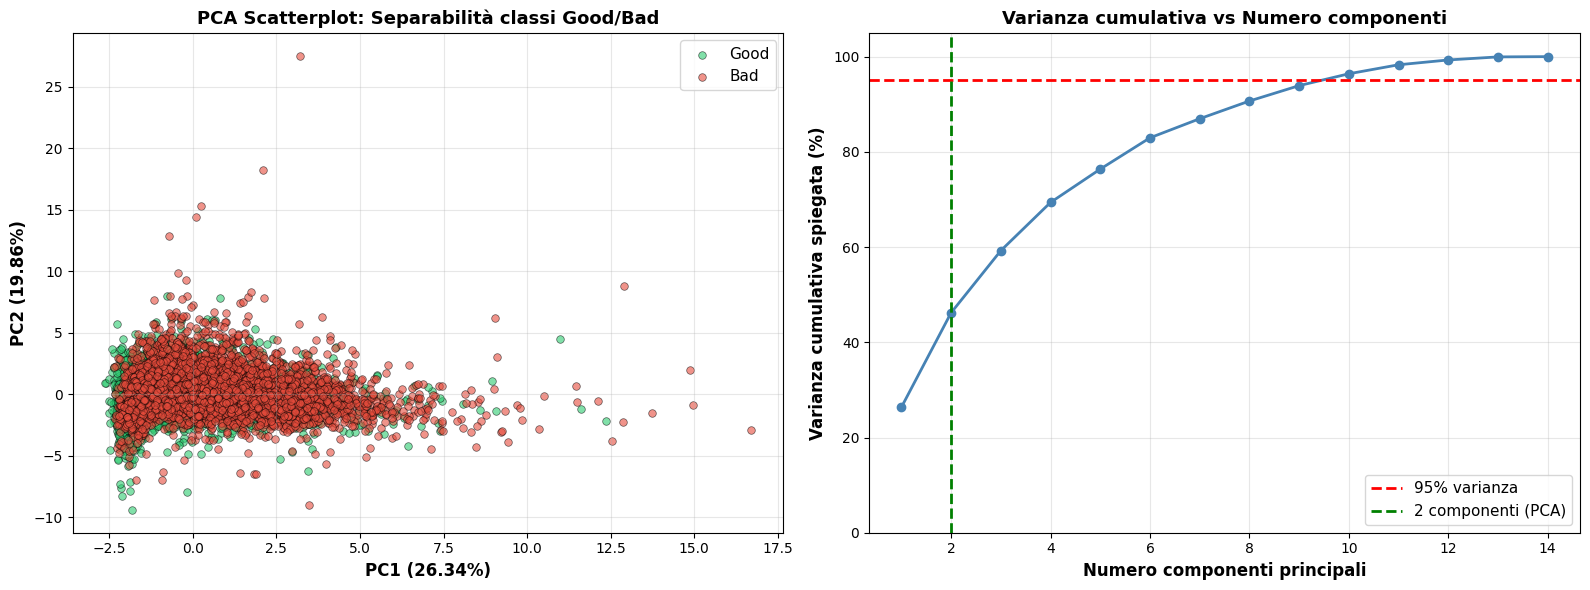

✓ Plot PCA salvato: pca_analysis.png

STATISTICHE DI SEPARABILITA':
  Centro classe Good: (-0.674, -0.213)
  Centro classe Bad:  (0.622, 0.196)
  Distanza tra centroidi: 1.358

  Interpretazione: ~ Media separabilità - le classi hanno un discreto grado di separazione


In [12]:
# Analisi PCA e visualizzazione separabilità classi Good/Bad

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Caricamento dataset finale
df = pd.read_csv('../../../data/processed/DatasetFinali/heloc_dataset_cleanedDLLM.csv')

print("ANALISI PCA - SEPARABILITA' CLASSI Good/Bad\n")

# Separazione feature e target
X = df.drop(columns=['RiskPerformance'])
y = df['RiskPerformance']

# Selezione solo colonne numeriche per PCA
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X_numeric = X[numeric_cols]

print(f"Feature numeriche utilizzate: {len(numeric_cols)}")
print(f"Campioni: {len(X_numeric)}")
print(f"Distribuzione classi:")
print(y.value_counts())
print(f"Percentuali: \n{y.value_counts(normalize=True) * 100}\n")

# Standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# PCA - Prime 2 componenti
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Varianza spiegata
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"Varianza spiegata dalle componenti:")
print(f"  PC1: {explained_var[0]:.4f} ({explained_var[0]*100:.2f}%)")
print(f"  PC2: {explained_var[1]:.4f} ({explained_var[1]*100:.2f}%)")
print(f"  Totale: {cumulative_var[1]:.4f} ({cumulative_var[1]*100:.2f}%)\n")

# Creazione scatterplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot colorato per classe
colors = {'Good': '#2ecc71', 'Bad': '#e74c3c'}
for class_label in ['Good', 'Bad']:
    mask = y == class_label
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], 
                   c=colors[class_label], label=class_label, 
                   alpha=0.6, s=30, edgecolors='black', linewidth=0.5)

axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.2f}%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.2f}%)', fontsize=12, fontweight='bold')
axes[0].set_title('PCA Scatterplot: Separabilità classi Good/Bad', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='best')
axes[0].grid(True, alpha=0.3)

# Varianza spiegata cumulativa
n_components_range = range(1, min(len(numeric_cols)+1, 21))
pca_all = PCA(n_components=min(len(numeric_cols), 20))
pca_all.fit(X_scaled)
cumulative_variance_all = np.cumsum(pca_all.explained_variance_ratio_)

axes[1].plot(range(1, len(cumulative_variance_all)+1), cumulative_variance_all*100, 
            marker='o', linewidth=2, markersize=6, color='steelblue')
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% varianza')
axes[1].axvline(x=2, color='green', linestyle='--', linewidth=2, label='2 componenti (PCA)')
axes[1].set_xlabel('Numero componenti principali', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Varianza cumulativa spiegata (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Varianza cumulativa vs Numero componenti', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('../../../data/processed/Fase1/Plot/pca_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot PCA salvato: pca_analysis.png")

# Statistiche di separabilità
print(f"\nSTATISTICHE DI SEPARABILITA':")
good_mean = X_pca[y == 'Good'].mean(axis=0)
bad_mean = X_pca[y == 'Bad'].mean(axis=0)
distance = np.linalg.norm(good_mean - bad_mean)

print(f"  Centro classe Good: ({good_mean[0]:.3f}, {good_mean[1]:.3f})")
print(f"  Centro classe Bad:  ({bad_mean[0]:.3f}, {bad_mean[1]:.3f})")
print(f"  Distanza tra centroidi: {distance:.3f}")
print(f"\n  Interpretazione: ", end="")
if distance > 2:
    print("✓ Buona separabilità - le classi sono ben distinguibili nello spazio PCA")
elif distance > 1:
    print("~ Media separabilità - le classi hanno un discreto grado di separazione")
else:
    print("✗ Scarsa separabilità - le classi sono molto sovrapposte")

ANALISI DELLE DISTRIBUZIONI - DATASET FINALE

Dimensioni dataset: 9,861 righe × 24 colonne

Tipi di dato:
int64    14
str      10
Name: count, dtype: int64
STATISTICHE DESCRITTIVE - COLONNE NUMERICHE
       ExternalRiskEstimate  MSinceMostRecentTradeOpen  AverageMInFile  \
count           9861.000000                9861.000000     9861.000000   
mean              72.060440                   9.520535       78.744245   
std                9.871795                  12.288235       33.904646   
min               33.000000                   0.000000        4.000000   
25%               64.000000                   3.000000       57.000000   
50%               72.000000                   6.000000       76.000000   
75%               80.000000                  12.000000       97.000000   
max               94.000000                 227.000000      322.000000   

       NumSatisfactoryTrades  NumTrades60Ever2DerogPubRec  \
count            9861.000000                  9861.000000   
mean       

/var/folders/8g/3_yjjvpn7113xq7pfkgkcbzr0000gn/T/ipykernel_3030/3558843694.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_final.select_dtypes(include=['object']).columns.tolist()


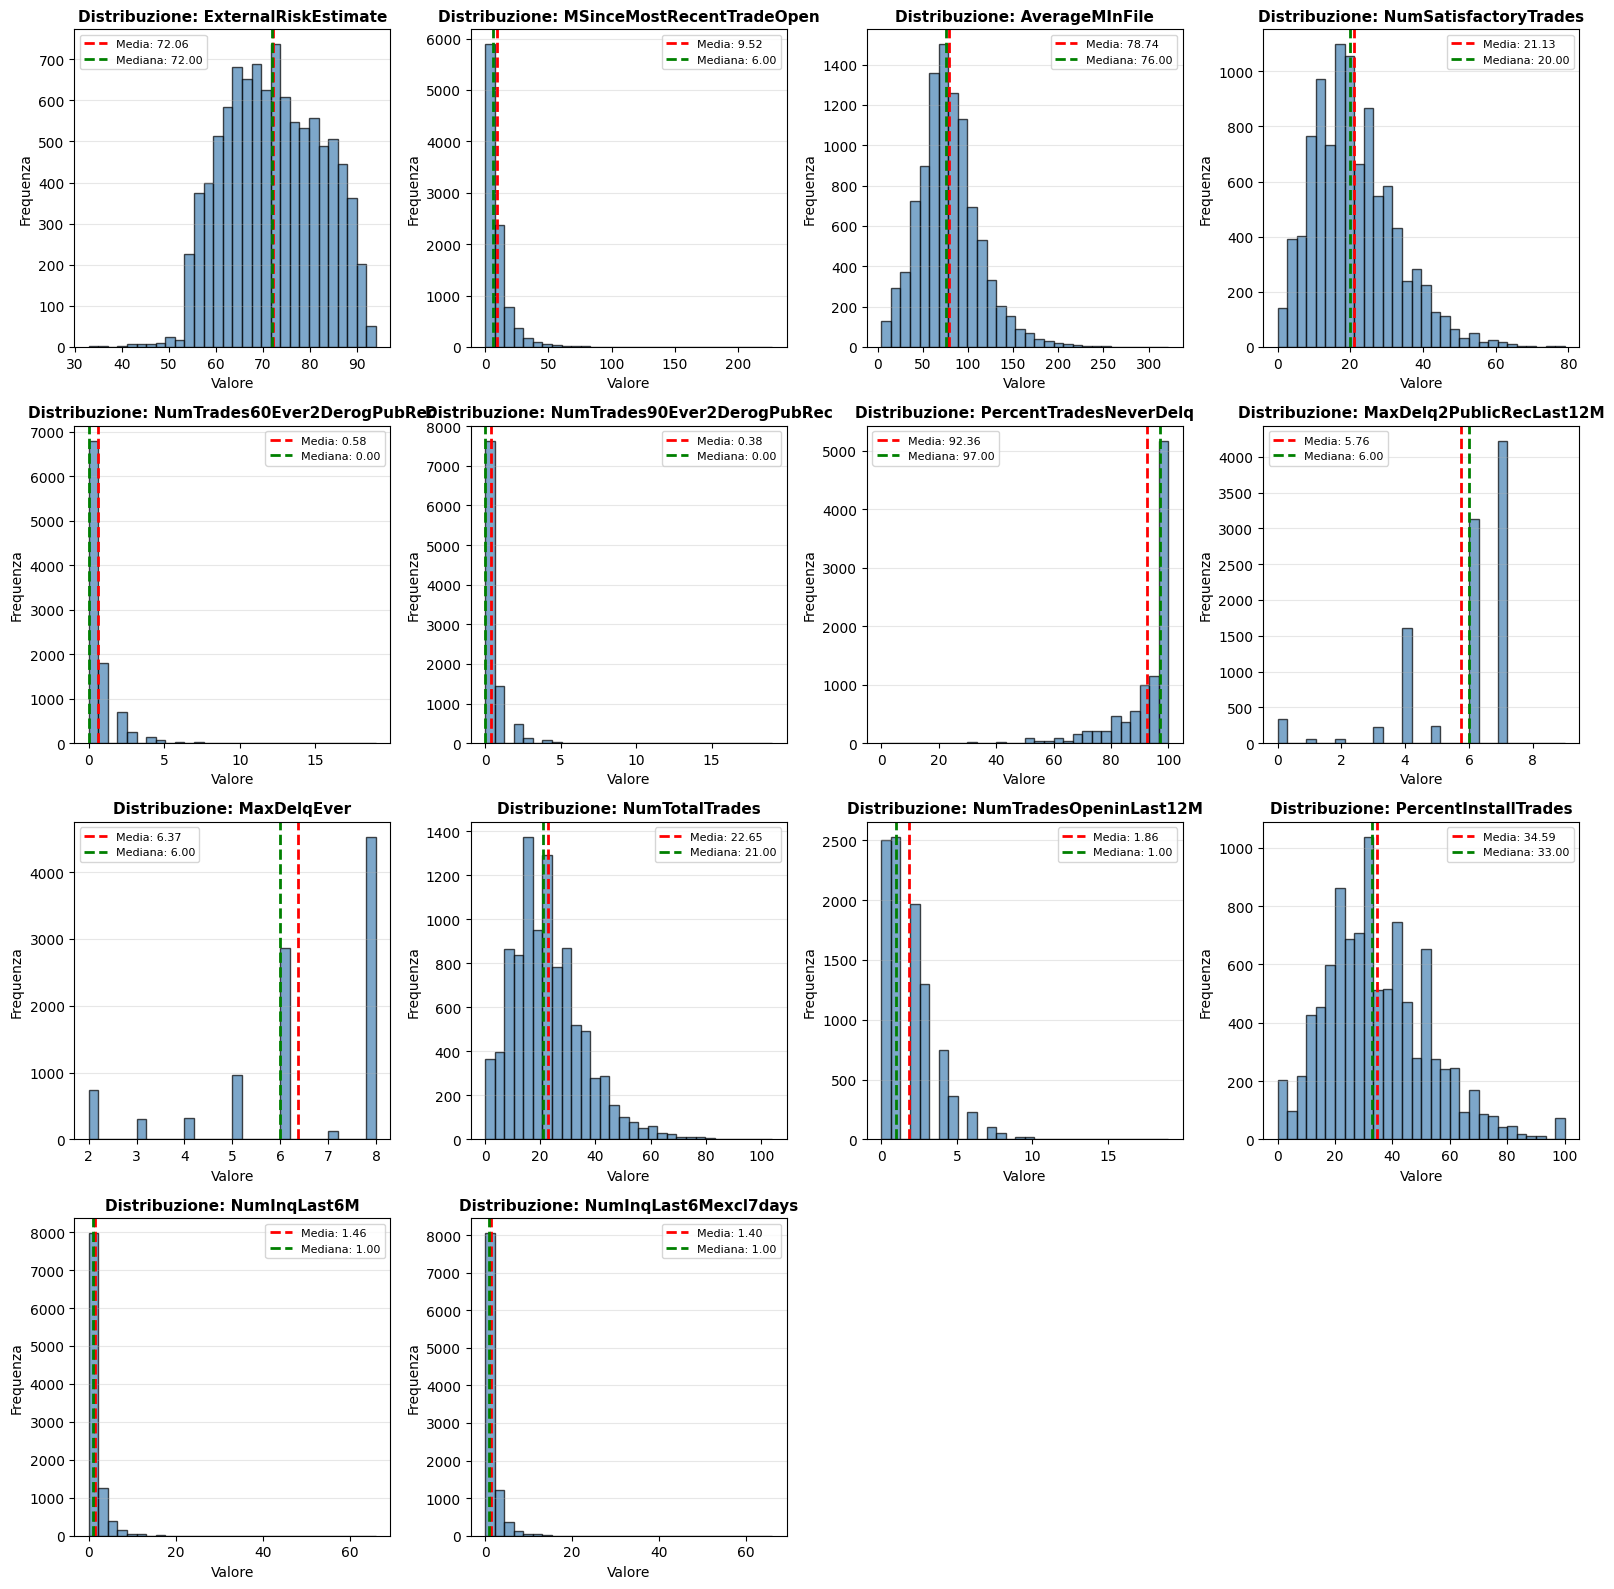

✓ Plot salvato: distribuzioni_numeriche.png

Generazione box plot per outlier detection...


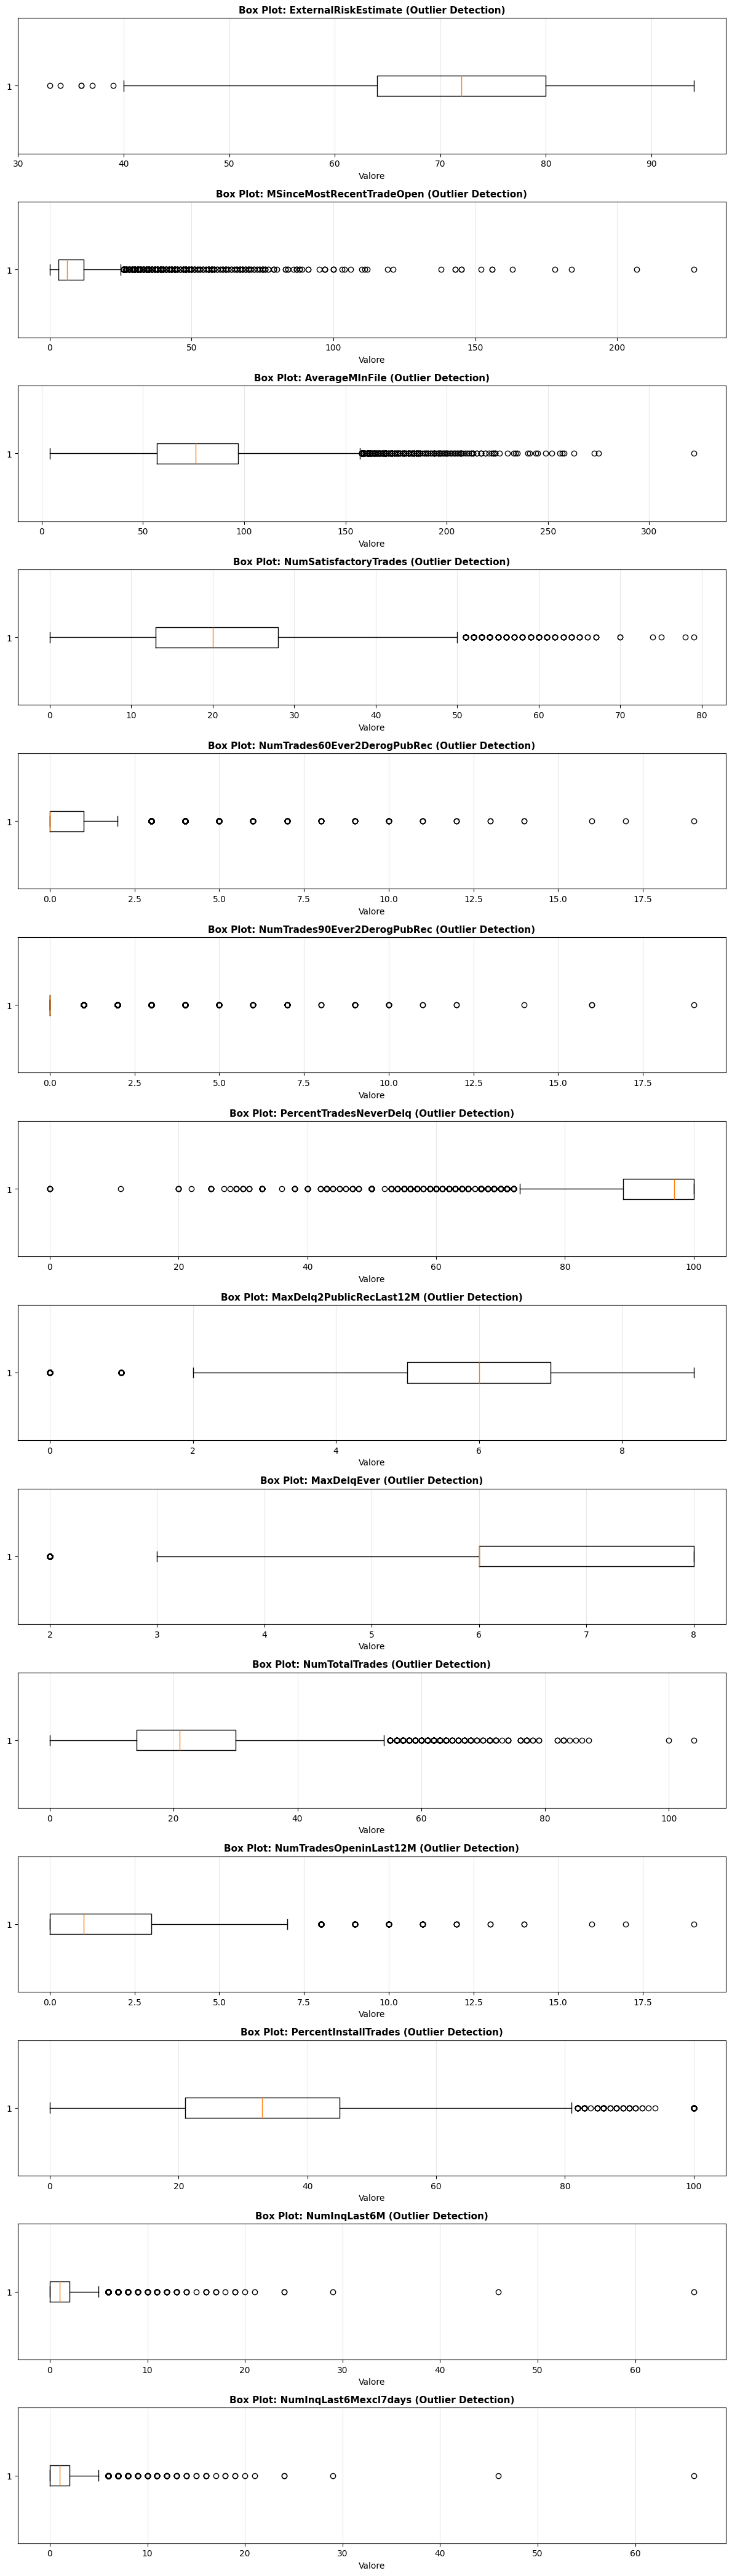

Plot salvato: boxplot_outliers.png

Generazione plot distribuzioni categoriche...


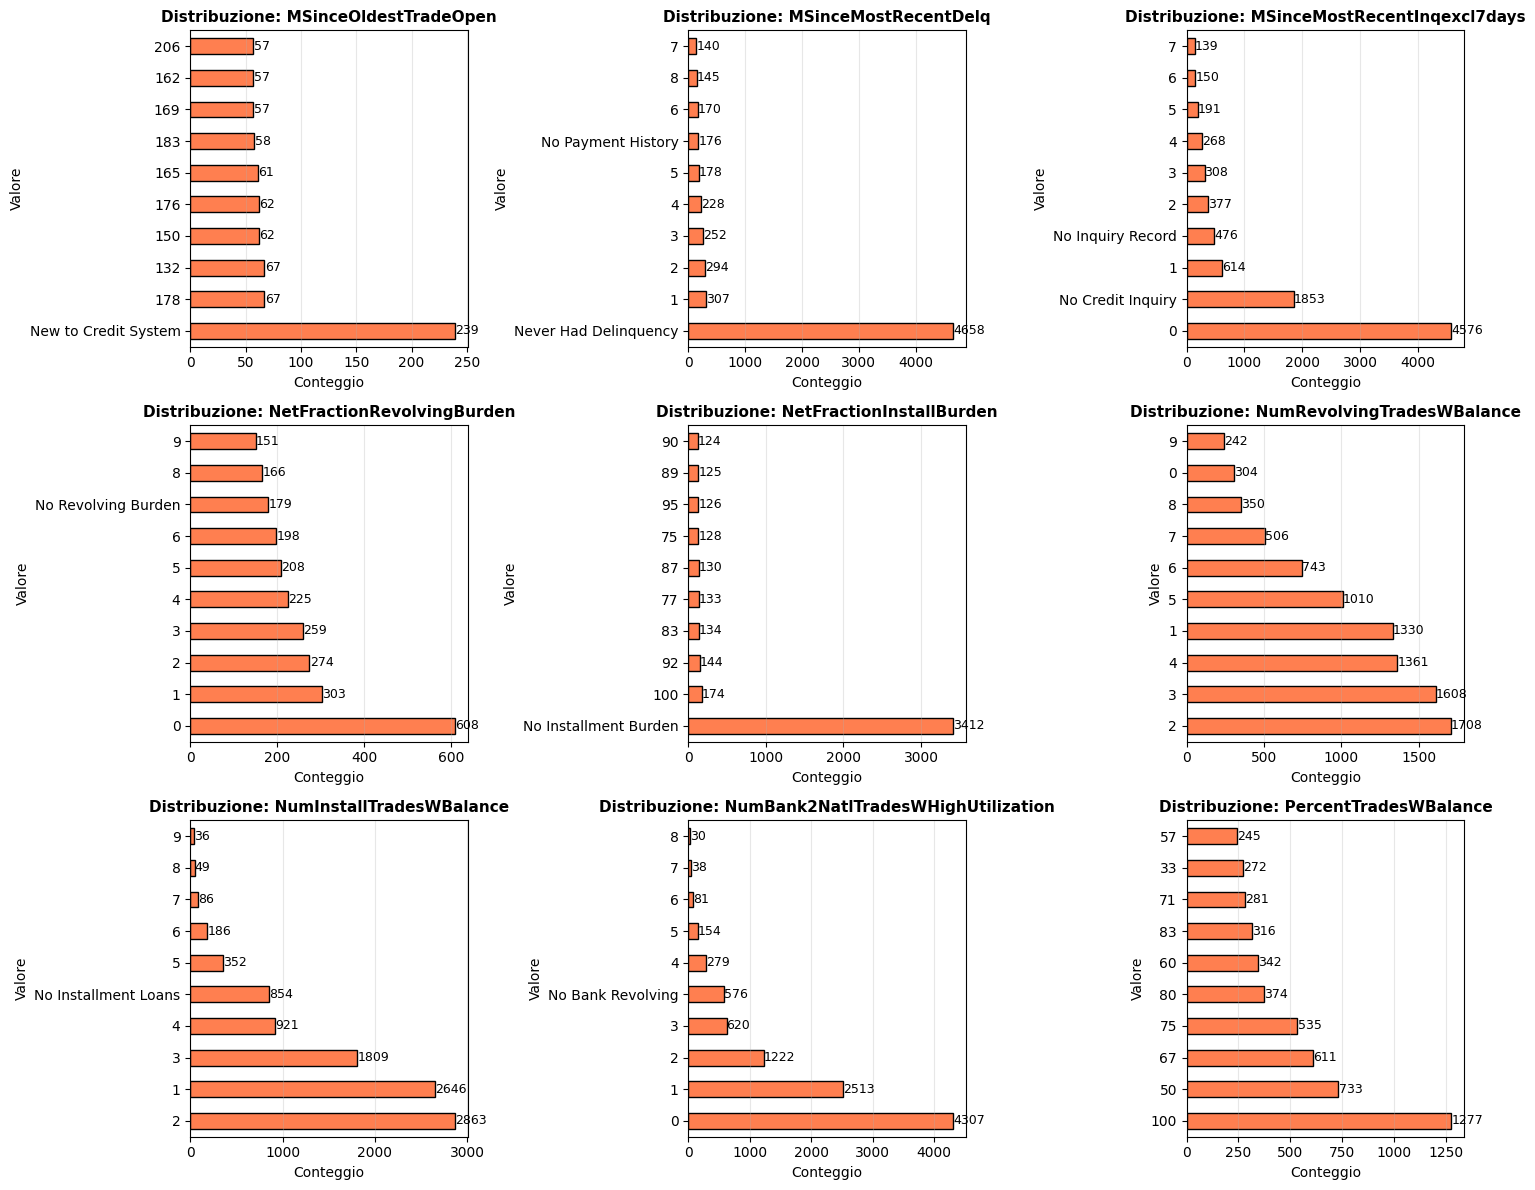

Plot salvato: distribuzioni_categoriche.png

Generazione plot target distribution...


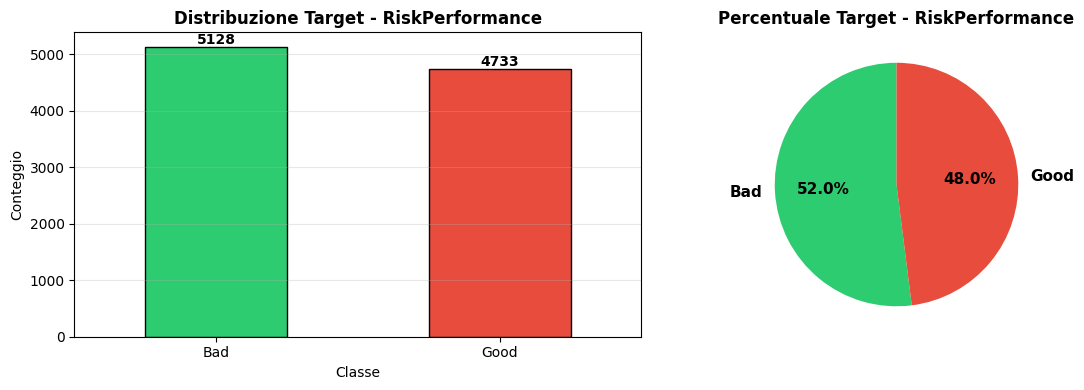

Plot salvato: target_distribution.png


In [13]:
# Analisi delle distribuzioni del dataset finale

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset finale
df_final = pd.read_csv('../../../data/processed/DatasetFinali/heloc_dataset_cleanedDLLM.csv')


print("ANALISI DELLE DISTRIBUZIONI - DATASET FINALE")


# Informazioni generali
print(f"\nDimensioni dataset: {df_final.shape[0]:,} righe × {df_final.shape[1]} colonne")
print(f"\nTipi di dato:")
print(df_final.dtypes.value_counts())

# Statistiche descrittive per colonne numeriche

print("STATISTICHE DESCRITTIVE - COLONNE NUMERICHE")

numeric_stats = df_final.describe()
print(numeric_stats)

# Conteggio di valori mancanti

print("VALORI MANCANTI")

missing_count = df_final.isnull().sum()
if missing_count.sum() > 0:
    print(missing_count[missing_count > 0].sort_values(ascending=False))
else:
    print("Nessun valore mancante nel dataset")

# Separazione colonne numeriche e categoriche
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_final.select_dtypes(include=['object']).columns.tolist()


print(f"COMPOSIZIONE FEATURE")

print(f"Colonne numeriche: {len(numeric_cols)}")
print(f"Colonne categoriche: {len(categorical_cols)}")

# Distribuzione della variabile target (RiskPerformance)

print("DISTRIBUZIONE TARGET - RiskPerformance")

if 'RiskPerformance' in df_final.columns:
    target_dist = df_final['RiskPerformance'].value_counts()
    print(target_dist)
    print(f"\nPercentuali:")
    print(df_final['RiskPerformance'].value_counts(normalize=True) * 100)
else:
    print("Colonna 'RiskPerformance' non trovata")

# Visualizzazione 1: Distribuzioni numeriche
if numeric_cols:

    print("Generazione plot distribuzioni numeriche...")

    
    # Calcola layout griglia
    n_cols = 4
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
    axes_flat = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes_flat[idx]
        
        
        ax.hist(df_final[col].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(f'Distribuzione: {col}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Valore', fontsize=10)
        ax.set_ylabel('Frequenza', fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        
        
        mean_val = df_final[col].mean()
        median_val = df_final[col].median()
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        ax.legend(fontsize=8)
    
    # Rimuovi assi vuoti
    for idx in range(len(numeric_cols), len(axes_flat)):
        fig.delaxes(axes_flat[idx])
    
    plt.tight_layout()
    plt.savefig('../../../data/processed/Fase1/Plot/distribuzioni_numeriche.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Plot salvato: distribuzioni_numeriche.png")

# Visualizzazione 2: Box plot per outlier detection (numeriche)
if numeric_cols:
    print(f"\nGenerazione box plot per outlier detection...")
    
    fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(12, 3*len(numeric_cols)))
    if len(numeric_cols) == 1:
        axes = [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        ax.boxplot(df_final[col].dropna(), vert=False)
        ax.set_title(f'Box Plot: {col} (Outlier Detection)', fontsize=11, fontweight='bold')
        ax.set_xlabel('Valore', fontsize=10)
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../../../data/processed/Fase1/Plot/boxplot_outliers.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Plot salvato: boxplot_outliers.png")

# Visualizzazione 3: Distribuzioni categoriche
if categorical_cols:
    print(f"\nGenerazione plot distribuzioni categoriche...")
    
    # Escludere target se presente
    cat_cols_plot = [col for col in categorical_cols if col != 'RiskPerformance']
    
    if cat_cols_plot:
        n_cols = 3
        n_rows = (len(cat_cols_plot) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        axes_flat = axes.flatten() if len(cat_cols_plot) > 1 else [axes]
        
        for idx, col in enumerate(cat_cols_plot):
            ax = axes_flat[idx]
            
            value_counts = df_final[col].value_counts().head(10)  # Top 10
            value_counts.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
            ax.set_title(f'Distribuzione: {col}', fontsize=11, fontweight='bold')
            ax.set_xlabel('Conteggio', fontsize=10)
            ax.set_ylabel('Valore', fontsize=10)
            ax.grid(axis='x', alpha=0.3)
            
            # Aggiungi conteggi
            for i, v in enumerate(value_counts.values):
                ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
        
        # Rimuovi assi vuoti
        for idx in range(len(cat_cols_plot), len(axes_flat)):
            fig.delaxes(axes_flat[idx])
        
        plt.tight_layout()
        plt.savefig('../../../data/processed/Fase1/Plot/distribuzioni_categoriche.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("Plot salvato: distribuzioni_categoriche.png")

# Visualizzazione 4: Target distribution
if 'RiskPerformance' in df_final.columns:
    print(f"\nGenerazione plot target distribution...")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Bar plot
    target_counts = df_final['RiskPerformance'].value_counts()
    target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[0].set_title('Distribuzione Target - RiskPerformance', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Classe', fontsize=10)
    axes[0].set_ylabel('Conteggio', fontsize=10)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Aggiungi conteggi
    for i, (idx, v) in enumerate(target_counts.items()):
        axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
    
    # Pie chart
    colors = ['#2ecc71', '#e74c3c']
    axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', 
                colors=colors, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Percentuale Target - RiskPerformance', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../../../data/processed/Fase1/Plot/target_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Plot salvato: target_distribution.png")
